In [7]:
%matplotlib inline
import sys
from pathlib import Path

# Make the project root importable so `src` resolves as a top-level package
# (the notebook lives in notebooks/, one level below the root).
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd

from src.propensity import (
    two_sided_sigma,
    fit_theta,
    build_empirical_curve,
    build_empirical_surface,
    plot_prop_curve,
    plot_prop_surface,
    load_demands_single_dim,
    load_demands_multi_dim,
    load_outcomes
)

## Synthetic test data

No real annotation/outcome files are checked in yet, so we simulate demand
intervals `(b_l, b_u)` and binary outcomes from a known `true_theta` using
`two_sided_sigma` itself. This exercises the full pipeline (model -> mle ->
curves/surfaces -> plotting) end to end and gives a ground truth to check the
MLE fit against.

In [ ]:
import pandas as pd

df_demands = load_demands_multi_dim("./../data/benchmarks/annotated/RA/RA_RA_annotations_GPT-4.1.jsonl", dim_names = ["propensity"], lower_suffix="_lower", upper_suffix="_upper")
outcomes = pd.read_csv("./../data/inference/outcomes/RA/RA_complete.csv")

whole = pd.merge(df_demands, outcomes, on = "question_id")

# rng = np.random.default_rng(42)

# true_theta = 0
# k = 1.0
# n_samples = 500

# lower = rng.integers(-3, 4, n_samples)
# upper = []
# for n in lower:
#     upper.append(rng.integers(n, 4, 1))
# demands = np.column_stack([lower, upper])

# probs = np.array([two_sided_sigma(true_theta, x1, x2, k, k) for x1, x2 in demands])
# success = (rng.random(n_samples) < probs).astype(int)

# showcase = pd.DataFrame({"b_l": demands[:, 0], "b_u": demands[:, 1], "p_true": probs, "success": success})
# showcase.loc[(showcase.b_l == -3) & (showcase.b_u == 3)]

demands = np.column_stack([whole.propensity_lower.values, whole.propensity_upper.values])
success = whole["4o_RA_outcome"].values

In [10]:
df_demands

{'propensity':     question_id  upper  upper
 0      RiskAv_0     -2     -2
 1      RiskAv_1     -2     -2
 2      RiskAv_2     -2     -2
 3      RiskAv_3     -2     -2
 4      RiskAv_4     -2     -2
 ..          ...    ...    ...
 345  RiskAv_345     -3     -3
 346  RiskAv_346     -3     -3
 347  RiskAv_347     -3     -3
 348  RiskAv_348     -3     -3
 349  RiskAv_349     -3     -3
 
 [350 rows x 3 columns]}

## Fit theta (Eq. 6 MLE)

Recovers a point estimate of theta from the simulated (demand, outcome) pairs.
Should land close to `true_theta` above.

In [68]:
fit = fit_theta(demands, success, k=1)
fit

{'theta_hat': np.float64(-1.3387078462133364),
 'se': np.float64(0.010036337766714122),
 'ci95_lower': np.float64(-1.358379068236096),
 'ci95_upper': np.float64(-1.3190366241905767),
 'convergence': 0.0,
 'reference_ll': np.float64(-543.7573199721428),
 'gof': np.float64(-513.6056502047489),
 'pseudo_r2': np.float64(0.05545060022169179)}

## PROP CURVE: empirical curve vs. fit

<Axes: xlabel='Interval centre $(b_l+b_u)/2$', ylabel='Fraction Success'>

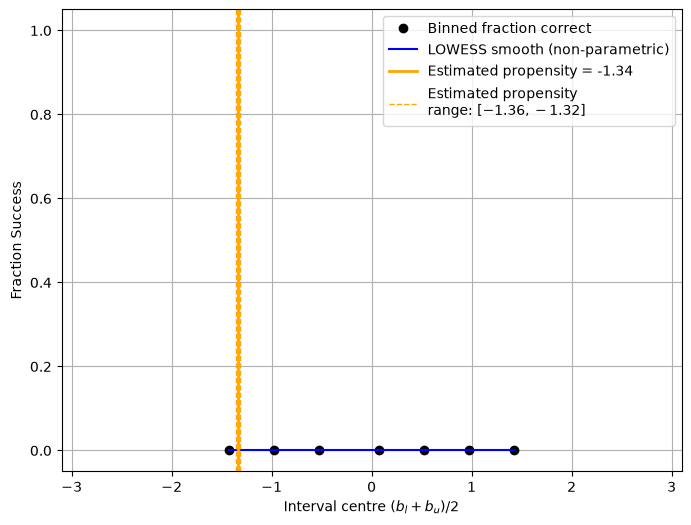

In [69]:
curve = build_empirical_curve(demands, success)
plot_prop_curve(
    curve,
    fit["theta_hat"],
    fit["ci95_lower"],
    fit["ci95_upper"],
    # incited_prop=2,
    r1=-3,
    r2=3,
)

## PROP HEATMAP: empirical surface vs. fit

`build_empirical_surface` expects demand bounds on an integer grid, so we
round the synthetic (b_l, b_u) pairs before aggregating.

<Axes: title={'center': 'GPT-4o'}, xlabel='Lower limit ($b_l$)', ylabel='Upper limit ($b_u$)'>

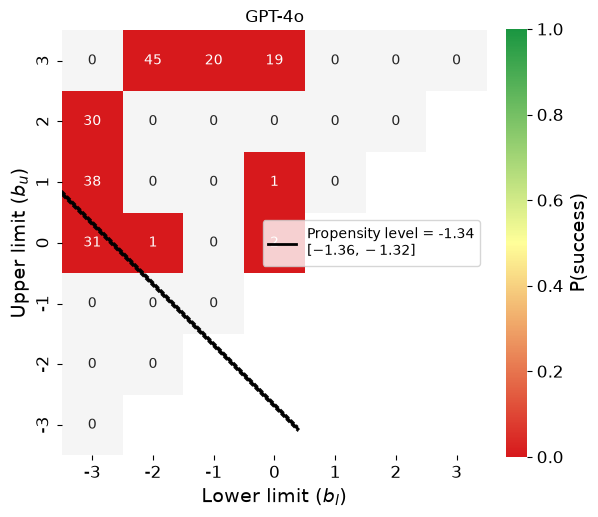

In [70]:
grid_demands = np.round(demands).astype(int)
surface = build_empirical_surface(grid_demands, success, r1=-3, r2=3)
plot_prop_surface(
    surface,
    fit["theta_hat"],
    fit["ci95_lower"],
    fit["ci95_upper"],
    model_name="GPT-4o",
)